# **🏠House Price Prediction — Ames Housing Dataset**

This notebook builds a linear regression model to predict house sale prices using the Ames Housing dataset from Kaggle. The goal is to demonstrate a complete machine learning pipeline — from exploratory data analysis and feature selection through preprocessing and model evaluation.

The project covers the following steps: exploratory data analysis using univariate, bivariate and multivariate visualizations, feature selection based on correlation and scatter plot analysis, data cleaning including outlier removal, categorical encoding using `pd.get_dummies()`, feature scaling with `StandardScaler`, log transformation of the target variable to correct right skew, and model training and evaluation using R² and RMSE.

**Dataset:** 1460 houses with 79 original features — 11 selected for this project  
**Target variable:** `SalePrice` — the sale price of each house in dollars

## **Setup & Data Loading**

We begin by importing the necessary libraries and loading only the features selected
after an initial review of the dataset. Features were chosen to cover a mix of
numeric and categorical variables relevant to house pricing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

df = pd.read_csv('data/train.csv', usecols=['GrLivArea','OverallQual','OverallCond','GarageArea','BedroomAbvGr','TotalBsmtSF','YearBuilt','LotArea','Neighborhood','BldgType','FullBath','SalePrice'])
print(df.shape)
print(df.head())

(1460, 12)
   LotArea Neighborhood BldgType  OverallQual  OverallCond  YearBuilt  \
0     8450      CollgCr     1Fam            7            5       2003   
1     9600      Veenker     1Fam            6            8       1976   
2    11250      CollgCr     1Fam            7            5       2001   
3     9550      Crawfor     1Fam            7            5       1915   
4    14260      NoRidge     1Fam            8            5       2000   

   TotalBsmtSF  GrLivArea  FullBath  BedroomAbvGr  GarageArea  SalePrice  
0          856       1710         2             3         548     208500  
1         1262       1262         2             3         460     181500  
2          920       1786         2             3         608     223500  
3          756       1717         1             3         642     140000  
4         1145       2198         2             4         836     250000  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LotArea       1460 non-null   int64 
 1   Neighborhood  1460 non-null   object
 2   BldgType      1460 non-null   object
 3   OverallQual   1460 non-null   int64 
 4   OverallCond   1460 non-null   int64 
 5   YearBuilt     1460 non-null   int64 
 6   TotalBsmtSF   1460 non-null   int64 
 7   GrLivArea     1460 non-null   int64 
 8   FullBath      1460 non-null   int64 
 9   BedroomAbvGr  1460 non-null   int64 
 10  GarageArea    1460 non-null   int64 
 11  SalePrice     1460 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 137.0+ KB


In [3]:
df.describe()

,LotArea,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,GrLivArea,FullBath,BedroomAbvGr,GarageArea,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,6.099315,5.575342,1971.267808,1057.429452,1515.463699,1.565068,2.866438,472.980137,180921.195890
std,9981.264932,1.382997,1.112799,30.202904,438.705324,525.480383,0.550916,0.815778,213.804841,79442.502883
min,1300.000000,1.000000,1.000000,1872.000000,0.000000,334.000000,0.000000,0.000000,0.000000,34900.000000
25%,7553.500000,5.000000,5.000000,1954.000000,795.750000,1129.500000,1.000000,2.000000,334.500000,129975.000000
50%,9478.500000,6.000000,5.000000,1973.000000,991.500000,1464.000000,2.000000,3.000000,480.000000,163000.000000
75%,11601.500000,7.000000,6.000000,2000.000000,1298.250000,1776.750000,2.000000,3.000000,576.000000,214000.000000
max,215245.000000,10.000000,9.000000,2010.000000,6110.000000,5642.000000,3.000000,8.000000,1418.000000,755000.000000


In [4]:
print(df.isna().sum())

LotArea         0
Neighborhood    0
BldgType        0
OverallQual     0
OverallCond     0
YearBuilt       0
TotalBsmtSF     0
GrLivArea       0
FullBath        0
BedroomAbvGr    0
GarageArea      0
SalePrice       0
dtype: int64


**Validation Check:** There are no missing values in the dataset.

## **Categorical Features Overview**

Checking the distribution of categories in `Neighborhood` and `BldgType` to understand how many unique values exist and whether any category dominates the data.

In [5]:
print(df['Neighborhood'].value_counts())
print(df['BldgType'].value_counts())

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64
BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64


## **Target Distribution**

`SalePrice` is right skewed — the majority of houses sold between 100k and 200k with a long tail stretching toward 750k. A log transformation will be applied to compress the tail and produce a more symmetric distribution, as shown in the plot below.

Text(0.5, 0, 'log(SalePrice)')

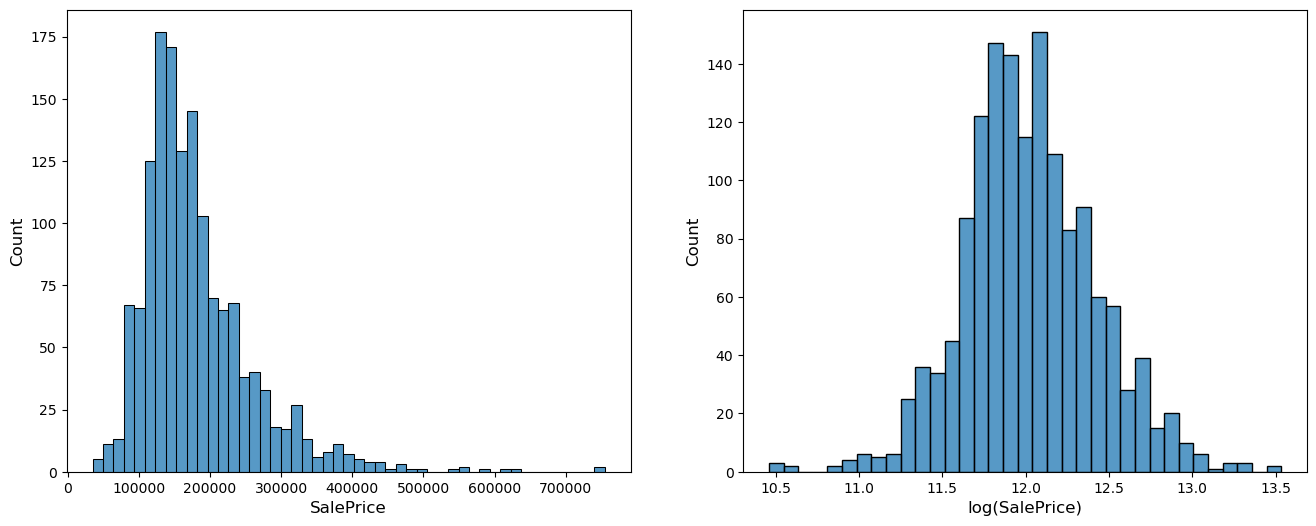

In [6]:
f, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['SalePrice'], ax=ax[0])
sns.histplot(np.log(df['SalePrice']), ax=ax[1])
ax[1].set_xlabel('log(SalePrice)')

After applying `np.log()`, `SalePrice` now follows a near-symmetric bell curve centered around 12 — which corresponds to approximately 163k, the median house price. The long tail has been compressed and the distribution is now suitable for linear regression. The model will be trained on these log values and predictions will be converted back to real dollar values using `np.exp()` before evaluation.

## **Numeric Features Distribution**

Plotting the distribution of all numeric features to detect skewness, outliers, and low-variation columns that may not contribute meaningful signal to the model.

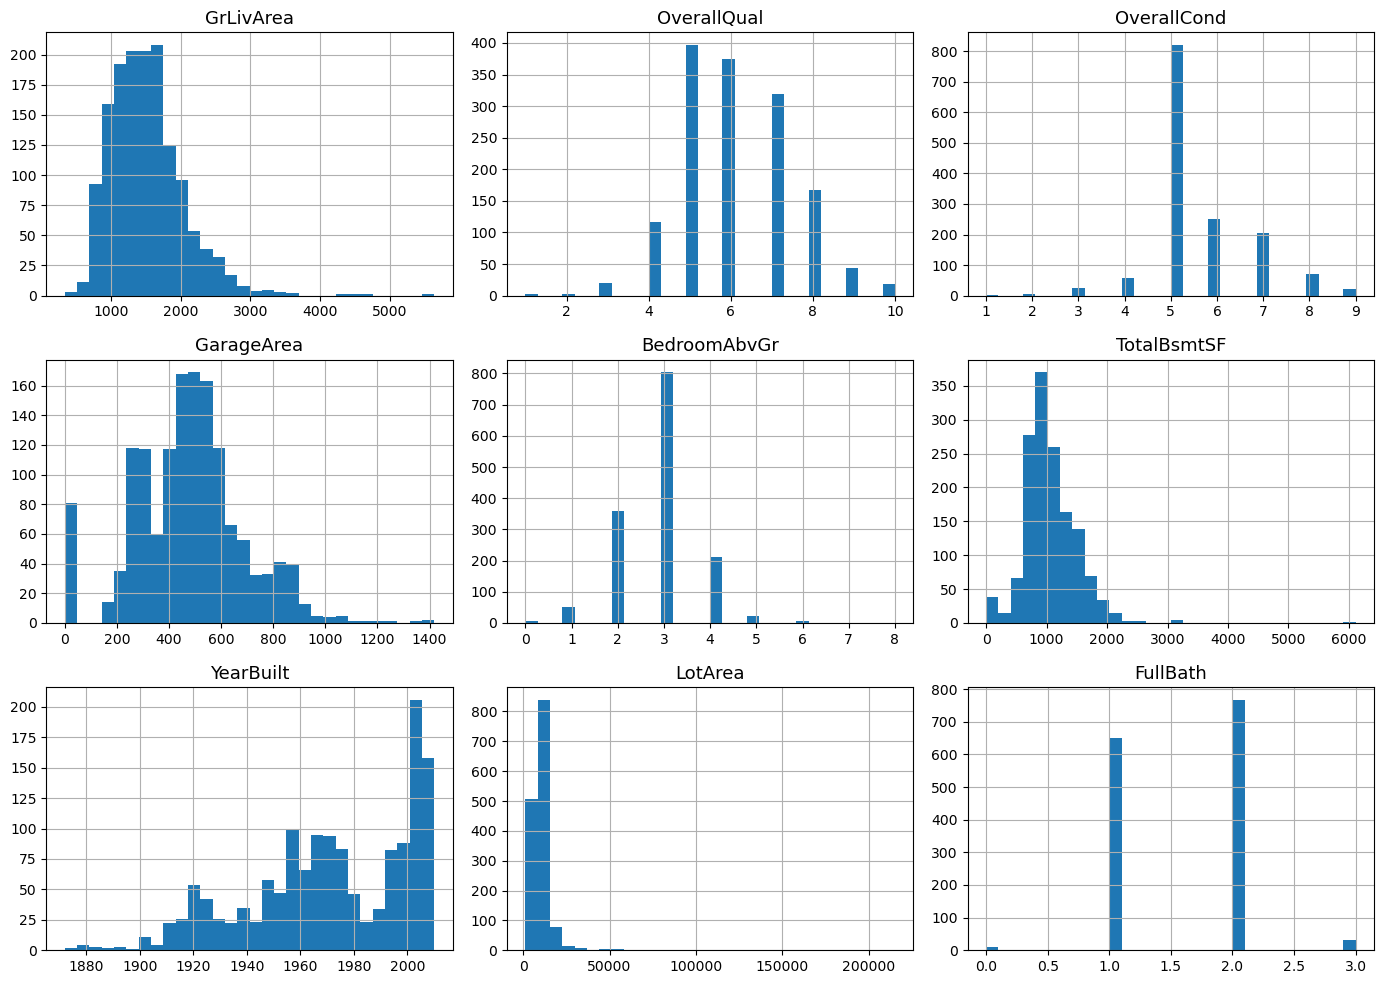

In [7]:
numeric_cols=['GrLivArea','OverallQual','OverallCond','GarageArea','BedroomAbvGr','TotalBsmtSF','YearBuilt','LotArea','FullBath']
df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

- `GrLivArea` and `LotArea` show strong right skew with extreme outliers that compress the main cluster
- `OverallCond` is concentrated at 5 for over 55% of houses — too little variation to be useful, will be dropped
- `BedroomAbvGr` is dominated by 3 bedrooms — similarly low variation, will be dropped
- Remaining features show reasonable distributions suitable for modeling

## **BldgType vs SalePrice**

Boxplot showing how sale price is distributed across each building type, to confirm whether this categorical feature separates price meaningfully enough to keep.

<Axes: xlabel='BldgType', ylabel='SalePrice'>

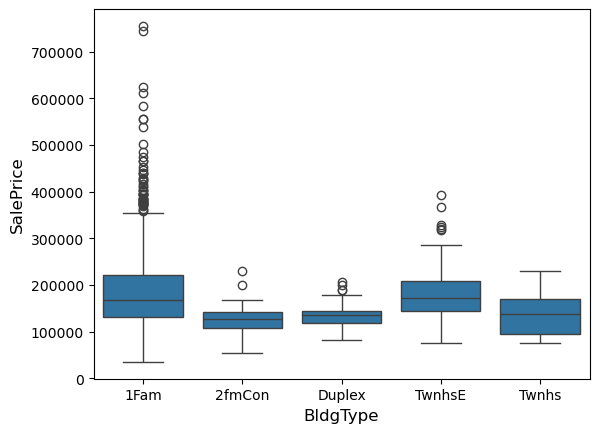

In [8]:
sns.boxplot(x='BldgType', y='SalePrice', data=df)

`1Fam` and `TwnhsE` have noticeably higher medians and wider price ranges than `2fmCon`, `Duplex`, and `Twnhs`. The clear separation between categories confirms that `BldgType` carries meaningful price signal and will be kept. The many outlier circles above `1Fam` reflect the skewed `SalePrice` distribution seen earlier.

## **Neighborhood vs SalePrice**

Boxplot showing how sale price is distributed across each of the 25 neighborhoods to confirm whether this categorical feature separates price meaningfully enough to keep.

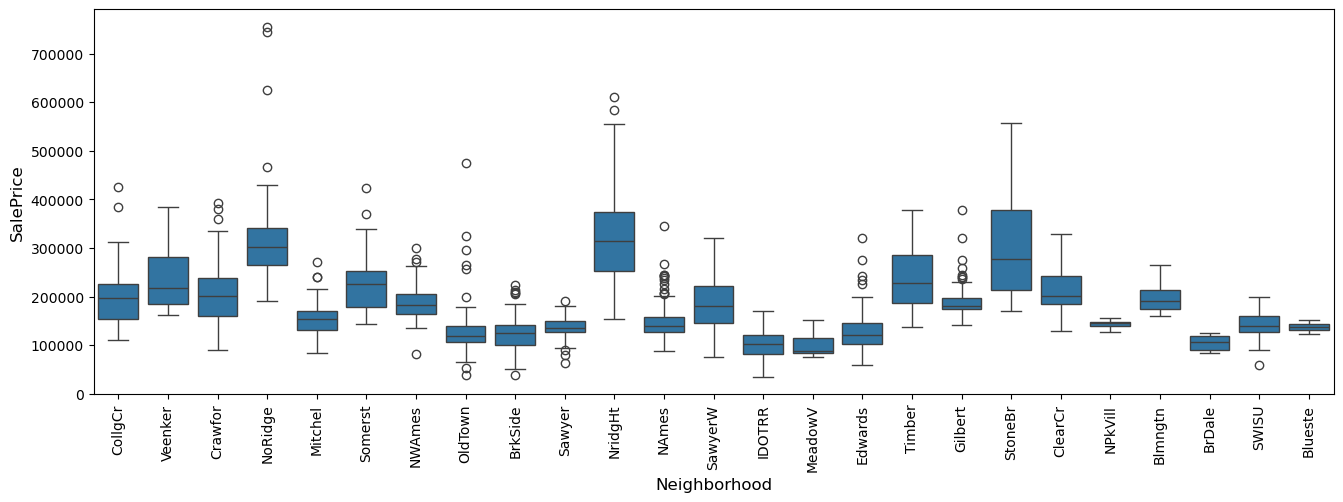

In [9]:
plt.figure(figsize=(16, 5))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.show()

The price separation across neighborhoods is dramatic — `NridgHt` and `StoneBr` have medians around 300k while `MeadowV`, `IDOTRR`, and `BrDale` sit around 100k. That is a 3x price difference purely based on location, confirming that `Neighborhood` is one of the most powerful features in the dataset and will be kept. This aligns with the well-known real estate principle that location drives price more than almost any other factor.

## **Feature Correlation with SalePrice**

Ranking all numeric features by their linear correlation with `SalePrice` to identify which features are worth investigating further and which are candidates for removal.

In [10]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix['SalePrice'].sort_values(ascending=False))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageArea      0.623431
TotalBsmtSF     0.613581
FullBath        0.560664
YearBuilt       0.522897
LotArea         0.263843
BedroomAbvGr    0.168213
OverallCond    -0.077856
Name: SalePrice, dtype: float64


`OverallQual` (0.79) and `GrLivArea` (0.71) are the strongest predictors. `GarageArea`, `TotalBsmtSF`, `FullBath`, and `YearBuilt` show moderate but meaningful correlations above 0.5. `LotArea` at 0.26 is borderline and will be confirmed visually through scatter plots. `BedroomAbvGr` at 0.17 and `OverallCond` at -0.08 are too weak — both will be dropped, consistent with the low variation observed in their distributions above.

## **Scatter Plots**

Visualizing features to confirm the shape of their relationship with `SalePrice` and validate keep or drop decisions.

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

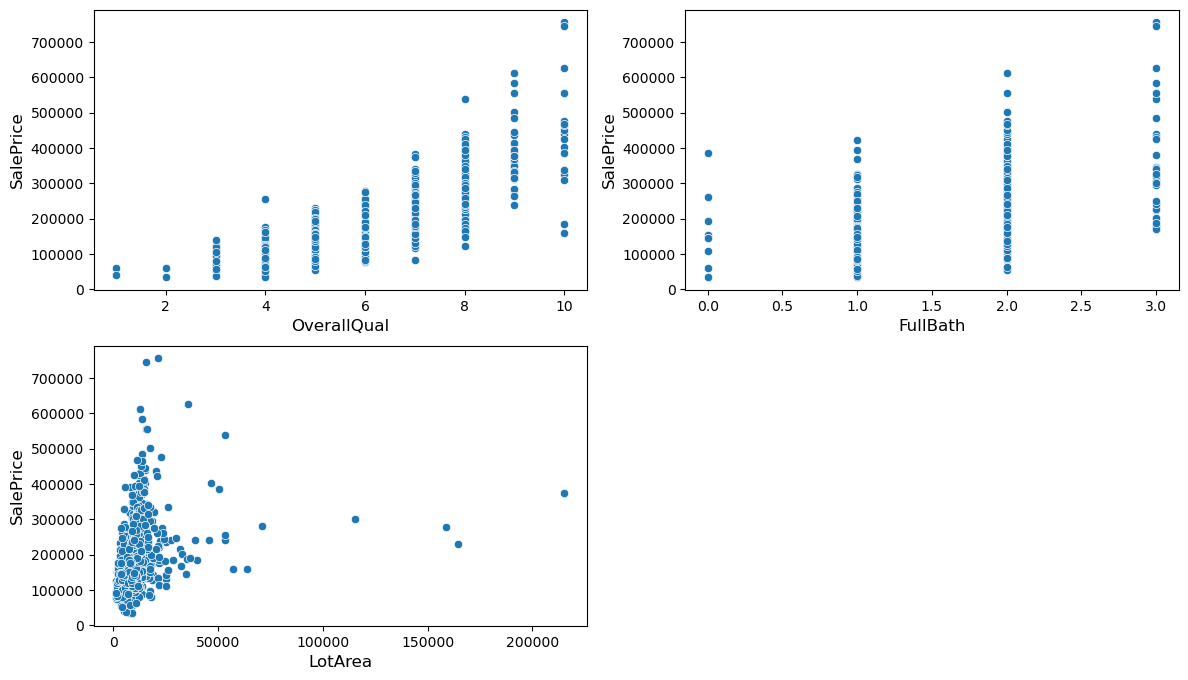

In [11]:
f, ax = plt.subplots(2, 2, figsize=(14, 8))
sns.scatterplot(data=df,x='OverallQual',y='SalePrice',ax=ax[0,0])
sns.scatterplot(data=df,x='FullBath',y='SalePrice',ax=ax[0,1])
sns.scatterplot(data=df,x='LotArea',y='SalePrice',ax=ax[1,0])
ax[1,1].axis('off')

- `OverallQual` confirms a strong upward curve — prices accelerate noticeably above quality 6, validating its 0.79 correlation
- `FullBath` shows a weak upward trend with massive vertical spread at each value — too little separation to justify keeping, will be dropped
- `LotArea` shows all points compressed into the left edge — the relationship is too distorted to be useful, will be dropped

<Axes: xlabel='GarageArea', ylabel='SalePrice'>

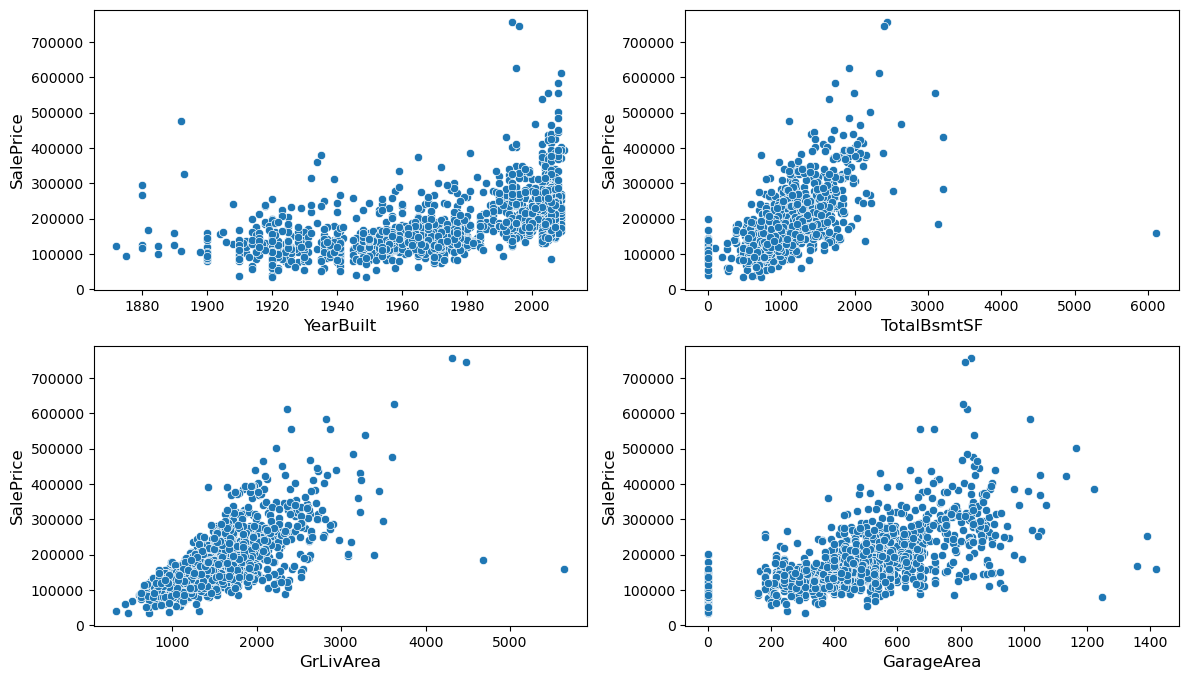

In [12]:
f, ax = plt.subplots(2, 2, figsize=(14, 8))
sns.scatterplot(data=df,x='YearBuilt',y='SalePrice',ax=ax[0,0])
sns.scatterplot(data=df,x='TotalBsmtSF',y='SalePrice',ax=ax[0,1])
sns.scatterplot(data=df,x='GrLivArea',y='SalePrice',ax=ax[1,0])
sns.scatterplot(data=df,x='GarageArea',y='SalePrice',ax=ax[1,1])

- `YearBuilt` shows a clear upward curve — prices accelerate sharply post-1980 and again post-2000, a strong case for polynomial regression
- `TotalBsmtSF` shows a mostly linear upward trend with a cluster of zeros for houses with no basement and a few high-end outliers
- `GrLivArea` shows the strongest and clearest upward pattern with two notable outliers — large houses that sold far below expected price — which will be removed
- `GarageArea` shows a moderate upward trend with a vertical cluster at zero for houses with no garage, similar in structure to `TotalBsmtSF`

## **Feature Correlation Heatmap**

Checking correlations between features themselves to detect redundancy. If two features correlate strongly with each other, the weaker one relative to `SalePrice` will be dropped to avoid multicollinearity.

<Axes: >

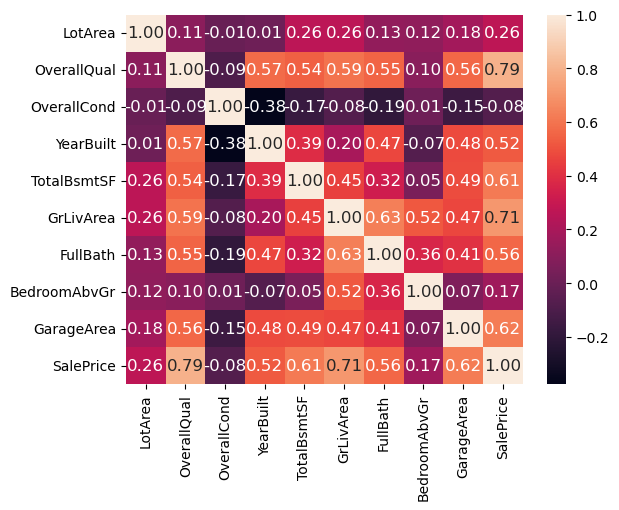

In [13]:
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f')

- No two features in the final kept set exceed 0.7 correlation with each other, meaning no critical multicollinearity to worry about

## **Feature Selection & Data Cleaning**

Based on the EDA findings, weak features are dropped and outliers identified in the scatter plots are removed before modeling.

**Dropped features:** `OverallCond`, `BedroomAbvGr`, `FullBath`, and `LotArea` — low correlation, low variation, or distorted distributions.

**Removed outliers:** extreme values in `GrLivArea`, `TotalBsmtSF`, and `GarageArea` that compress the main cluster and would disproportionately influence the model.

In [14]:
#run once
df=df.drop(columns=['OverallCond', 'BedroomAbvGr', 'FullBath', 'LotArea'])
df = df[df['GrLivArea'] < 4500]
df = df[df['TotalBsmtSF'] < 3000]
df = df[df['GarageArea'] < 1200]
print(df.shape)
print(df.columns.tolist())

(1451, 8)
['Neighborhood', 'BldgType', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'SalePrice']


## **Encoding Categorical Features**

`Neighborhood` and `BldgType` are nominal categorical features. To make them suitable for machine learning models, I transformed these variables into binary (dummy) columns using one-hot encoding.

In [15]:
#run once
df = pd.get_dummies(df, columns=['Neighborhood', 'BldgType'], drop_first=True)
print(df.shape)

(1451, 34)


## **Splitting the Data**

Separating features from the target variable, then splitting into training and test sets with 80/20 ratio. The log transformation is applied to `SalePrice` at this stage to correct the right skew observed during EDA — the model will train on log prices and predictions will be converted back to real dollars with `np.exp()` after inference.

In [16]:
X=df.drop('SalePrice', axis=1)
y=df['SalePrice']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log=np.log(y_train)
y_test_log=np.log(y_test)

## **Feature Scaling**

Applying `StandardScaler` to normalize all numeric features to the same scale. Fitted on training data only to prevent data leakage — the same learned statistics are then applied to the test set.

In [17]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## **Linear Regression**

Training a baseline linear regression model on the scaled features and log-transformed target. Predictions are converted back to real dollar values with `np.exp()` before evaluation. R² measures how much variance the model explains and RMSE measures the average prediction error in dollars.

In [18]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log)
y_pred_log=lr.predict(X_test_scaled)
y_pred_actual=np.exp(y_pred_log)

print("MSE: ",np.sqrt(mean_squared_error(y_test, y_pred_actual)))
print("R squared: ",metrics.r2_score(y_test, y_pred_actual))

MSE:  24611.739089797153
R squared:  0.9024708887798786


The linear regression model achieves an R² of 0.90, meaning it explains 90% of the variance in house prices. The RMSE of approximately 24,600 dollars represents the average prediction error — roughly 15% of the median house price of 163k. This is a strong baseline result driven largely by the Neighborhood encoding and the strong numeric features retained after feature selection.

## **Residual Plot — Linear Regression**

Plotting the residuals to diagnose how well the linear model captured the relationships in the data. A good fit shows points scattered randomly around zero with no visible pattern. Any curve or U-shape would indicate a missed non-linear relationship and justify polynomial regression.

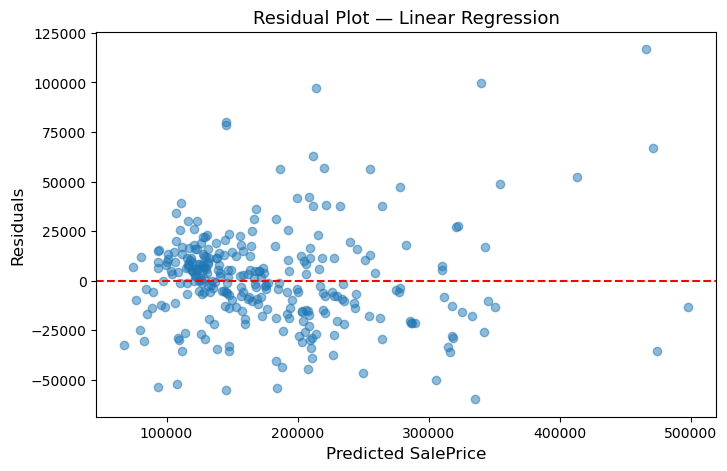

In [19]:
residuals = y_test - y_pred_actual
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_actual, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals')
plt.title('Residual Plot — Linear Regression')
plt.show()

The residuals scatter randomly around zero with no visible curve or U-shape, confirming that linear regression is appropriate for this dataset and polynomial regression is not needed. The spread widens slightly for higher predicted prices — a mild fan shape common in real estate data where expensive houses are harder to price precisely. A few extreme residuals beyond 75,000 dollars correspond to unusual houses the model struggled to price accurately, likely due to unique characteristics not captured by the selected features.

## **Checking for Overfitting**

Comparing R² on training data versus test data to check whether the model has overfit

In [20]:
print(lr.score(X_train_scaled, y_train_log))
print(lr.score(X_test_scaled, y_test_log))

0.8796869142654817
0.8658292518103643


Training R² of 0.88 and test R² of 0.87 are extremely close, confirming the model has not overfit. A large gap between the two would indicate overfitting but the difference of only 0.01 here means the model generalizes well to unseen data.

## **Conclusion**

This project demonstrates that thoughtful feature selection and preprocessing decisions matter as much as the choice of algorithm. Starting from 11 features, EDA guided the selection down to 5 numeric and 2 categorical features — each kept or dropped based on concrete visual and statistical evidence rather than guesswork.

The log transformation of `SalePrice` was a critical preprocessing step — without it the model would have been pulled toward expensive outlier houses at the cost of accuracy on the majority of normal-priced homes. Outlier removal in `GrLivArea`, `TotalBsmtSF` and `GarageArea` further cleaned the signal before any model saw the data.

`OverallQual` and `GrLivArea` emerged as the dominant numeric predictors, consistent with what the scatter plots revealed during EDA. `Neighborhood` proved equally important through one-hot encoding, confirming that location drives price more than almost any single numeric feature.

The residual plot showed no curve or systematic pattern, meaning the decision not to apply polynomial regression was data-driven rather than arbitrary — an important distinction in any serious analytical project.

A linear model trained on clean, well-selected features with appropriate target transformation is sufficient to explain 90% of house price variance on this dataset. The lesson is that a simple model done carefully outperforms a complex model applied carelessly.